# From Pro Forma to Operations — Reusing Your Bankable 3D Model

<span style="font-size:1.2em; color:#003591">
Design your plant once in SolarFarmer Desktop. Export the 3D model. Reuse it unchanged for operational monitoring —<br>
swap only the weather input, keep the same bankable physics engine.
</span>

---

In [1]:
import os
import re
from pathlib import Path
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pvlib.soiling import kimber

import solarfarmer as sf
from solcast import tmy, historic
from solcast.unmetered_locations import UNMETERED_LOCATIONS

# --- DNV plot style ---
DNV = {'navy': '#0f204b', 'blue': '#003591', 'sky': '#009fda',
       'light': '#99d9f0', 'green': '#3f9c35',
       'red': '#c0392b', 'soil': '#8B4513', 'warn': 'orange'}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7fbfe',
    'axes.edgecolor': DNV['navy'],
    'axes.labelcolor': DNV['navy'],
    'axes.titleweight': 'bold',
    'axes.titlecolor': DNV['blue'],
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': DNV['sky'],
    'xtick.color': DNV['navy'],
    'ytick.color': DNV['navy'],
    'font.family': 'Ubuntu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
})

# --- API keys ---
SF_API_KEY = os.environ["SF_API_KEY"]

sf.configure_logging()
print(f"SF_API_KEY:      {'set' if SF_API_KEY else 'MISSING'}")
print(f"SOLCAST_API_KEY: {'set' if os.environ.get('SOLCAST_API_KEY') else 'MISSING'}")

SF_API_KEY:      set
SOLCAST_API_KEY: set


## The 3D Model

Designed in **SolarFarmer Desktop** and exported via *File → Export API files*. The `EnergyCalcInputs.json` is the reusable artifact — same file for financing and operations.

![Fort Peck 3D Layout](operational_usecase/OperationalSite_Layout.png)

In [2]:
# Site coordinates — matches the exported 3D model
site = UNMETERED_LOCATIONS["Fort Peck"]
LATITUDE  = site["latitude"]
LONGITUDE = site["longitude"]

INPUTS_FOLDER = Path("operational_usecase")
JSON_FILE     = INPUTS_FOLDER / "EnergyCalcInputs.json"
PAN_FILES     = [str(INPUTS_FOLDER / "TrinaSolar_TSM-375DE14A(II)_APP.PAN")]
OND_FILES     = [str(INPUTS_FOLDER / "SMA_Highpower_SHP125_US_21_PEAK3.OND")]

print(f"Site: Fort Peck, Montana")
print(f"Lat/Lon: {LATITUDE}°N, {LONGITUDE}°E")
print(f"Model folder: {INPUTS_FOLDER.resolve()}")

Site: Fort Peck, Montana
Lat/Lon: 48.30783°N, -105.1017°E
Model folder: /home/iantse/git_repos/solarfarmer-sdk-examples/WebinarJune2026/operational_usecase


## Phase 1 — Preconstruction: TMY Bankable Yield

Establish the **financing baseline** — the P50 yield the project is underwritten against.

In [3]:
%%time
PARAMETERS = ["ghi", "dhi", "air_temp", "wind_speed_10m", "precipitation_rate"]

tmy_data = tmy.radiation_and_weather(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    output_parameters=PARAMETERS,
    period="PT60M",
).to_pandas()

# Export to SolarFarmer weather format
WEATHER_TMY = INPUTS_FOLDER / "weather_tmy.tsv"
sf.from_solcast(df=tmy_data, output_path=WEATHER_TMY)

print(f"TMY records: {len(tmy_data)} | Exported: {WEATHER_TMY}")
tmy_data.head()

TMY records: 8760 | Exported: operational_usecase/weather_tmy.tsv
CPU times: user 119 ms, sys: 20 ms, total: 139 ms
Wall time: 8.13 s


,air_temp,dhi,ghi,wind_speed_10m,precipitation_rate
period_end,,,,,
2059-01-01 01:00:00+00:00,-3.6,0,0,5.8,0
2059-01-01 02:00:00+00:00,-3.6,0,0,6.0,0
2059-01-01 03:00:00+00:00,-3.6,0,0,6.3,0
2059-01-01 04:00:00+00:00,-3.6,0,0,6.6,0
2059-01-01 05:00:00+00:00,-3.4,0,0,6.8,0


In [4]:
%%time
results_tmy = sf.run_energy_calculation(
    energy_calculation_inputs_file_path=JSON_FILE,
    meteorological_data_file_path=WEATHER_TMY,
    pan_file_paths=PAN_FILES,
    ond_file_paths=OND_FILES,
    project_id="lifecycle-preconstruction-tmy",
    api_key=SF_API_KEY,
    print_summary=True,
)

# Extract TMY timeseries for downstream comparison
ts_tmy = results_tmy.pvsyst_timeseries()
annual_tmy_mwh = ts_tmy['E_Grid'].sum() * 1.0 / 1e6  # Wh → MWh
print(f"Annual yield (TMY): {annual_tmy_mwh:,.1f} MWh")

INFO: Making API call to ModelChainAsync (3D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChainAsync
Start time = 02-06-2026 21:09:17
INFO: Instance ID returned = lifecycle-preconstruction-tmy_2026-06-03T040919_0ndemsvczn
INFO:  1: Time: 0:00:04 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO: Plant stats: 3D Trackers, AC = 0.625 MW
INFO:  2: Time: 0:00:09 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  3: Time: 0:00:14 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  4: Time: 0:00:19 	Run status: Running 	Custom status: Running shading pre-processing (0/54 tasks complete)  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  5: Time: 0:00:25 	Run status: Running 	Custom status: Running model chain calculation (0/46 tasks complete)  [Shading: 100.0%, ModelChain: 0.0%, Over

-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = lifecycle-preconstruction-tmy
Location (latitude, longitude, altitude) = 48.30783°, -105.10170°, 633.8 m
2D/3D = 3D calculation
Mounting type = Single-axis trackers
AC capacity of system = 0.625 MW
DC capacity of system = 0.729 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2059)
-------------------------------------  ----------------
Average annual temperature             6.60°C
Horizontal irradiation                 1449.72 kWh/m²
Irradiation on tilted plane            2068.53 kWh/m²
Effective irradiation on tilted plane  1997.04 kWh/m²
Energy yield                           1740.41 kWh/kWp
Net energy                             1268.75 MWh/year
Performance Ratio                      0.8414
-------------------------------------  --------------

## Phase 2 — Operational: Weather-Reconciled Performance

Same 3D model, swap only the weather file. Satellite actuals replace the TMY to answer: *is my plant performing as designed?*

In [5]:
%%time
# Hourly satellite actuals — Jan 2026 to present
_start = date(2026, 1, 1)
_today = date.today()
_duration_days = (_today - _start).days

def _fetch_historic(duration_days):
    return historic.radiation_and_weather(
        latitude=LATITUDE,
        longitude=LONGITUDE,
        start="2026-01-01T00:00",
        duration=f"P{duration_days}D",
        output_parameters=PARAMETERS,
        period="PT60M",
    ).to_pandas()

try:
    hist_data = _fetch_historic(_duration_days)
except Exception as e:
    msg = str(e)
    match = re.search(r'(\d{2}/\d{2}/\d{4})', msg)
    if match:
        limit_date = datetime.strptime(match.group(1), '%m/%d/%Y').date()
        _duration_days = (limit_date - _start).days
        # print(f"⚠ Solcast plan limit — capping to {limit_date} ({_duration_days} days)")
        hist_data = _fetch_historic(_duration_days)
    else:
        raise

WEATHER_HIST = INPUTS_FOLDER / "weather_historic.tsv"
sf.from_solcast(df=hist_data, output_path=WEATHER_HIST)

print(f"Historic records: {len(hist_data)} | {hist_data.index[0]} → {hist_data.index[-1]}")
hist_data.head()

Historic records: 3504 | 2026-01-01 01:00:00+00:00 → 2026-05-27 00:00:00+00:00
CPU times: user 87.1 ms, sys: 25.1 ms, total: 112 ms
Wall time: 6.64 s


,air_temp,dhi,ghi,precipitation_rate,wind_speed_10m
period_end,,,,,
2026-01-01 01:00:00+00:00,-7,0,0,0.0,3.0
2026-01-01 02:00:00+00:00,-7,0,0,0.0,2.9
2026-01-01 03:00:00+00:00,-8,0,0,0.0,2.8
2026-01-01 04:00:00+00:00,-8,0,0,0.0,2.6
2026-01-01 05:00:00+00:00,-9,0,0,0.0,2.4


In [6]:
%%time
results_hist = sf.run_energy_calculation(
    energy_calculation_inputs_file_path=JSON_FILE,
    meteorological_data_file_path=WEATHER_HIST,
    pan_file_paths=PAN_FILES,
    ond_file_paths=OND_FILES,
    project_id="lifecycle-operational-historic",
    api_key=SF_API_KEY,
    print_summary=True,
)

INFO: Making API call to ModelChainAsync (3D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChainAsync
Start time = 02-06-2026 21:11:32
INFO: Instance ID returned = lifecycle-operational-historic_2026-06-03T041134_v0xse52grs
INFO:  1: Time: 0:00:03 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO: Plant stats: 3D Trackers, AC = 0.625 MW
INFO:  2: Time: 0:00:09 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  3: Time: 0:00:14 	Run status: Running 	Custom status: Running shading pre-processing (0/54 tasks complete)  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  4: Time: 0:00:19 	Run status: Running 	Custom status: Running model chain calculation (0/17 tasks complete)  [Shading: 100.0%, ModelChain: 0.0%, Overall: 56.1%]
INFO:  5: Time: 0:00:24 	Run status: Running 	Custom status: Running model chain calculation (1/17 tasks complete)  [Shad

-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = lifecycle-operational-historic
Location (latitude, longitude, altitude) = 48.30783°, -105.10170°, 633.8 m
2D/3D = 3D calculation
Mounting type = Single-axis trackers
AC capacity of system = 0.625 MW
DC capacity of system = 0.729 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2026)
-------------------------------------  ---------------
Average annual temperature             1.68°C
Horizontal irradiation                 546.76 kWh/m²
Irradiation on tilted plane            775.76 kWh/m²
Effective irradiation on tilted plane  746.79 kWh/m²
Energy yield                           669.53 kWh/kWp
Net energy                             488.08 MWh/year
Performance Ratio                      0.8631
-------------------------------------  ---------------
CPU

### Performance Indices — Weekly Decomposition

Three metrics decompose observed performance into weather and plant contributions: **PII** (irradiance vs TMY), **PIE** (energy vs TMY), and **WA-PIE** (PIE normalised for irradiance — the plant's own fingerprint).

In [7]:
# ── Weekly Performance Indices ─────────────────────────────────────────────────
ts_hist = results_hist.pvsyst_timeseries()
DT_H = 1.0  # PT60M → 1 h per record

_hist_months = sorted(ts_hist.index.month.unique())
ts_tmy_match = ts_tmy[ts_tmy.index.month.isin(_hist_months)]

def by_week(ts, col, agg='sum', dt_hours=1.0):
    """Aggregate timeseries column by ISO week."""
    s = ts[col]
    week = s.index.isocalendar().week.values
    if agg == 'sum':
        return pd.Series(s.values * dt_hours, index=s.index).groupby(week).sum()
    return s.groupby(week).mean()

# Weekly energy (MWh) and POA (kWh/m²)
e_tmy_w    = by_week(ts_tmy_match, 'E_Grid', 'sum', dt_hours=DT_H) / 1e6
e_hist_w   = by_week(ts_hist,      'E_Grid', 'sum', dt_hours=DT_H) / 1e6
poa_tmy_w  = by_week(ts_tmy_match, 'GlobEffTotal', 'sum', dt_hours=DT_H) / 1e3
poa_hist_w = by_week(ts_hist,      'GlobEffTotal', 'sum', dt_hours=DT_H) / 1e3

common_weeks = e_tmy_w.index.intersection(e_hist_w.index)
e_tmy_w    = e_tmy_w.loc[common_weeks]
e_hist_w   = e_hist_w.loc[common_weeks]
poa_tmy_w  = poa_tmy_w.loc[common_weeks]
poa_hist_w = poa_hist_w.loc[common_weeks]

PII_w = (poa_hist_w / poa_tmy_w).values
PIE_w = (e_hist_w   / e_tmy_w).values
WA_PIE_w = ((e_hist_w / poa_hist_w) / (e_tmy_w / poa_tmy_w)).values

n_weeks = len(common_weeks)
x = np.arange(n_weeks)
week_labels = [f'W{w}' for w in common_weeks]
label_step = max(1, n_weeks // 12)

print(f"TMY predicted (matched weeks):  {e_tmy_w.sum():,.1f} MWh")
print(f"2026 actual simulated:          {e_hist_w.sum():,.1f} MWh")
print(f"Overall PIE:  {e_hist_w.sum() / e_tmy_w.sum():.3f}  "
      f"({(e_hist_w.sum() / e_tmy_w.sum() - 1)*100:+.1f}% vs TMY)")

TMY predicted (matched weeks):  500.7 MWh
2026 actual simulated:          488.1 MWh
Overall PIE:  0.975  (-2.5% vs TMY)


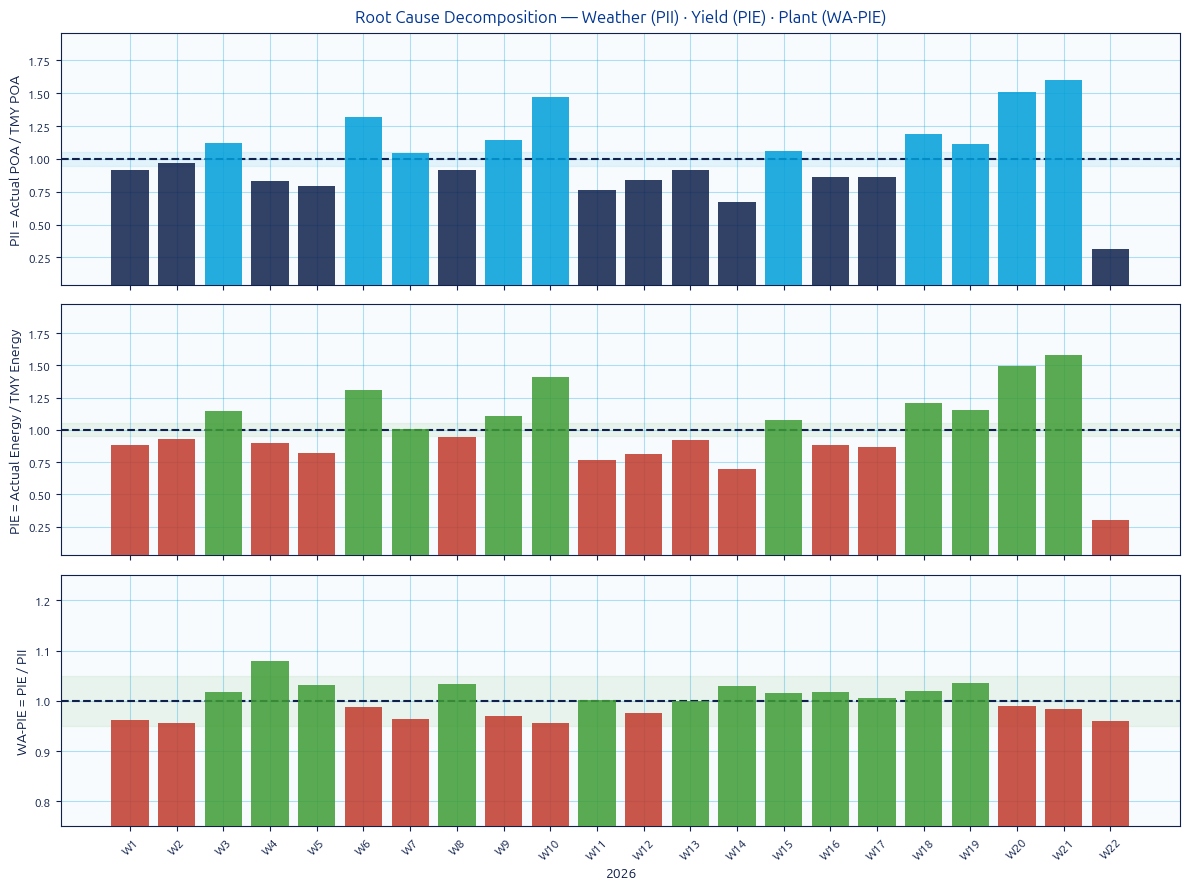

  Mean PII:    1.012   (above TMY insolation)
  Mean PIE:    1.010   (above TMY energy)
  Mean WA-PIE: 1.000   (worse than model)


In [8]:
# ── Root Cause Decomposition ───────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# PII
c_pii = [DNV['sky'] if v >= 1 else DNV['navy'] for v in PII_w]
ax1.bar(x, PII_w, color=c_pii, alpha=0.85, zorder=3)
ax1.axhline(1.0, color=DNV['navy'], linewidth=1.5, linestyle='--')
ax1.axhspan(0.95, 1.05, alpha=0.08, color=DNV['sky'])
margin_pii = max(0.25, float(np.abs(PII_w[np.isfinite(PII_w)] - 1).max()) * 1.4)
ax1.set_ylim(1 - margin_pii, 1 + margin_pii)
ax1.set_ylabel('PII = Actual POA / TMY POA')
ax1.set_title('Root Cause Decomposition — Weather (PII) · Yield (PIE) · Plant (WA-PIE)', pad=8)

# PIE
c_pie = [DNV['green'] if v >= 1 else DNV['red'] for v in PIE_w]
ax2.bar(x, PIE_w, color=c_pie, alpha=0.85, zorder=3)
ax2.axhline(1.0, color=DNV['navy'], linewidth=1.5, linestyle='--')
ax2.axhspan(0.95, 1.05, alpha=0.08, color=DNV['green'])
margin_pie = max(0.25, float(np.abs(PIE_w[np.isfinite(PIE_w)] - 1).max()) * 1.4)
ax2.set_ylim(1 - margin_pie, 1 + margin_pie)
ax2.set_ylabel('PIE = Actual Energy / TMY Energy')

# WA-PIE
wa_finite = WA_PIE_w[np.isfinite(WA_PIE_w)]
c_wapie = [DNV['green'] if v >= 0.99 else DNV['red'] for v in WA_PIE_w]
ax3.bar(x, WA_PIE_w, color=c_wapie, alpha=0.85, zorder=3)
ax3.axhline(1.0, color=DNV['navy'], linewidth=1.5, linestyle='--')
ax3.axhspan(0.95, 1.05, alpha=0.08, color=DNV['green'])
margin_wa = max(0.25, float(np.abs(wa_finite - 1).max()) * 1.4) if len(wa_finite) else 0.25
ax3.set_ylim(1 - margin_wa, 1 + margin_wa)
ax3.set_xticks(x[::label_step])
ax3.set_xticklabels(week_labels[::label_step], rotation=45)
ax3.set_ylabel('WA-PIE = PIE / PII')
ax3.set_xlabel('2026')

plt.tight_layout()
plt.show()

print(f"  Mean PII:    {np.nanmean(PII_w):.3f}   ({'above' if np.nanmean(PII_w) >= 1 else 'below'} TMY insolation)")
print(f"  Mean PIE:    {np.nanmean(PIE_w):.3f}   ({'above' if np.nanmean(PIE_w) >= 1 else 'below'} TMY energy)")
print(f"  Mean WA-PIE: {np.nanmean(WA_PIE_w):.3f}   ({'better' if np.nanmean(WA_PIE_w) >= 1 else 'worse'} than model)")

### Why Weather Adjusted PI ≠ 1.0

PV conversion is non-linear — temperature swings, diffuse/beam ratio, and inverter operating point all vary hour to hour. Running actual weather through the full model captures what a simple irradiance ratio cannot.

## Phase 3 — Introduce synthetic generation to simulated soiled operations

We drive SolarFarmer's per-timestep `Soiling` input directly from Solcast precipitation via the **pvlib Kimber model**. Three simulations, one 3D model: TMY baseline · clean actuals · soiled actuals.

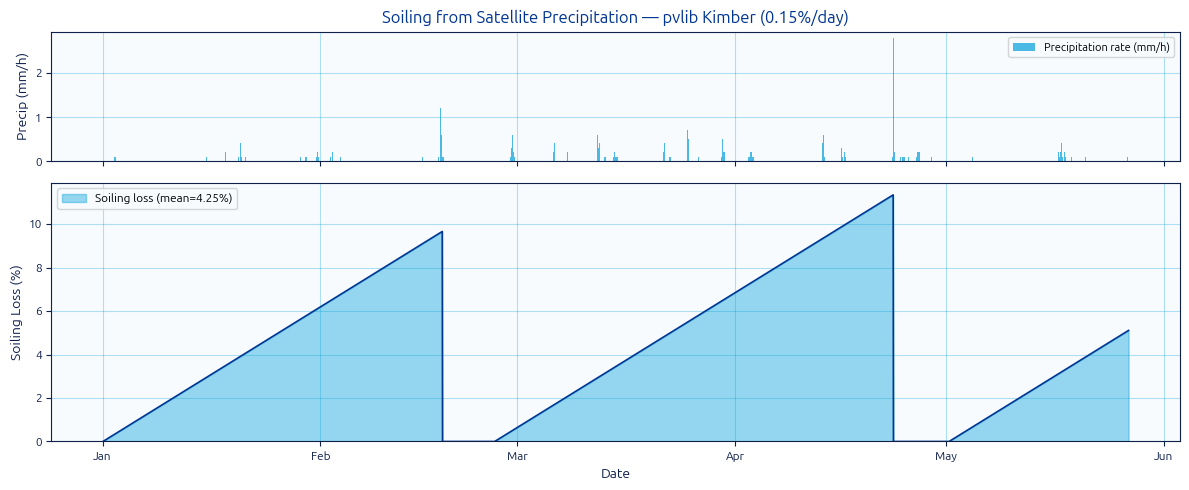

Soiling loss rate: 0.20%/day
Mean soiling loss: 4.25%
Peak soiling loss: 11.34%


In [9]:
# ── Compute Soiling from Precipitation (pvlib Kimber) ─────────────────────────
SOILING_LOSS_RATE = 0.002  # 0.2%/day

# kimber() returns soiling ratio (1 = clean); convert to loss fraction for SF
soiling_ratio = kimber(
    rainfall=hist_data['precipitation_rate'],
    soiling_loss_rate=SOILING_LOSS_RATE,
    grace_period=7,
)
soiling_loss = soiling_ratio

# Plot precipitation → soiling
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={'height_ratios': [1, 2]})

ax1.bar(hist_data.index, hist_data['precipitation_rate'], width=0.04,
        color=DNV['sky'], alpha=0.7, label='Precipitation rate (mm/h)')
ax1.set_ylabel('Precip (mm/h)')
ax1.set_title('Soiling from Satellite Precipitation — pvlib Kimber (0.15%/day)')
ax1.legend(loc='upper right', fontsize=8)

ax2.fill_between(hist_data.index, soiling_loss.values * 100, alpha=0.4, color=DNV['sky'],
                 label=f'Soiling loss (mean={soiling_loss.mean()*100:.2f}%)')
ax2.plot(hist_data.index, soiling_loss.values * 100, color=DNV['blue'], linewidth=1.2)
ax2.set_ylabel('Soiling Loss (%)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.set_ylim(bottom=0)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

print(f"Soiling loss rate: {SOILING_LOSS_RATE*100:.2f}%/day")
print(f"Mean soiling loss: {soiling_loss.mean()*100:.2f}%")
print(f"Peak soiling loss: {soiling_loss.max()*100:.2f}%")

In [10]:
%%time
# ── Inject soiling into weather and run SolarFarmer ───────────────────────────
hist_soiled = hist_data.copy()
hist_soiled['soiling'] = soiling_loss.values

WEATHER_SOILED = INPUTS_FOLDER / "weather_historic_soiled.tsv"
sf.from_solcast(df=hist_soiled, output_path=WEATHER_SOILED)

results_soiled = sf.run_energy_calculation(
    energy_calculation_inputs_file_path=JSON_FILE,
    meteorological_data_file_path=WEATHER_SOILED,
    pan_file_paths=PAN_FILES,
    ond_file_paths=OND_FILES,
    project_id="lifecycle-operational-soiled",
    api_key=SF_API_KEY,
    print_summary=True,
)

print(f"\nSoiled weather file: {WEATHER_SOILED}")
print(f"Soiling column range: {soiling_loss.min():.4f} – {soiling_loss.max():.4f}")

INFO: Making API call to ModelChainAsync (3D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChainAsync
Start time = 02-06-2026 21:13:49
INFO: Instance ID returned = lifecycle-operational-soiled_2026-06-03T041351_eb4ptstelt
INFO: Plant stats: 3D Trackers, AC = 0.625 MW
INFO:  1: Time: 0:00:03 	Run status: Running 	Custom status: Calculation pending...  [Shading: 0.0%, ModelChain: 0.0%, Overall: 0.0%]
INFO:  2: Time: 0:00:09 	Run status: Running 	Custom status: Running shading pre-processing (43/54 tasks complete)  [Shading: 79.6%, ModelChain: 0.0%, Overall: 40.6%]
INFO:  3: Time: 0:00:14 	Run status: Running 	Custom status: Running model chain calculation (0/17 tasks complete)  [Shading: 100.0%, ModelChain: 0.0%, Overall: 56.1%]
INFO:  4: Time: 0:00:19 	Run status: Running 	Custom status: Post-processing pending...  [Shading: 100.0%, ModelChain: 100.0%, Overall: 80.0%]
INFO:  5: Time: 0:00:26 	Run status: Completed 	Custom status: Finishing up.  [Shading: 100.0%, ModelChain: 100

-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = lifecycle-operational-soiled
Location (latitude, longitude, altitude) = 48.30783°, -105.10170°, 633.8 m
2D/3D = 3D calculation
Mounting type = Single-axis trackers
AC capacity of system = 0.625 MW
DC capacity of system = 0.729 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2026)
-------------------------------------  ---------------
Average annual temperature             1.68°C
Horizontal irradiation                 546.76 kWh/m²
Irradiation on tilted plane            775.76 kWh/m²
Effective irradiation on tilted plane  714.83 kWh/m²
Energy yield                           643.08 kWh/kWp
Net energy                             468.81 MWh/year
Performance Ratio                      0.8290
-------------------------------------  ---------------

Soil

### Three-Signal Comparison

The gap between expected (clean) and actual (soiled) is the signal a monitoring system should flag and quantify.

/tmp/ipykernel_108155/4145840346.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


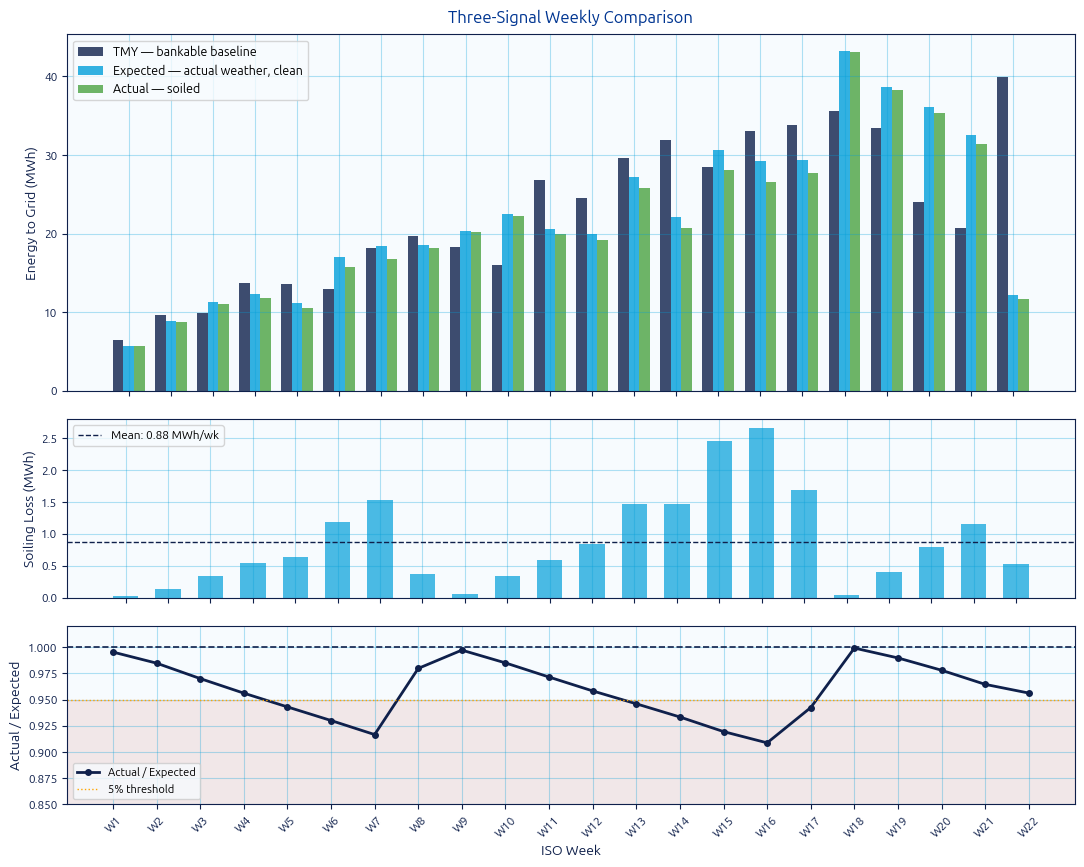

Total soiling loss: 19.3 MWh (3.9% of expected)
Worst week: 2.66 MWh | Mean ratio: 0.960


In [11]:
# ── Three-Signal Comparison: TMY / Expected / Actual ──────────────────────────
ts_soiled = results_soiled.pvsyst_timeseries()

e_soiled_w = by_week(ts_soiled, 'E_Grid', 'sum', dt_hours=DT_H) / 1e6
e_soiled_w = e_soiled_w.loc[common_weeks]
soiling_loss_w = e_hist_w - e_soiled_w  # MWh lost per week

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(13, 10),
    gridspec_kw={'height_ratios': [3, 1.5, 1.5], 'hspace': 0.12},
)

# Energy signals
w_bar = 0.25
ax1.bar(x - w_bar, e_tmy_w.values, w_bar, color=DNV['navy'], alpha=0.8,
        label='TMY — bankable baseline')
ax1.bar(x, e_hist_w.values, w_bar, color=DNV['sky'], alpha=0.8,
        label='Expected — actual weather, clean')
ax1.bar(x + w_bar, e_soiled_w.values, w_bar, color=DNV['green'], alpha=0.75,
        label='Actual — soiled')
ax1.set_xticks(x[::label_step]); ax1.set_xticklabels([])
ax1.set_ylabel('Energy to Grid (MWh)')
ax1.set_title('Three-Signal Weekly Comparison', pad=8)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(bottom=0)

# Soiling loss
ax2.bar(x, soiling_loss_w.values, 0.6, color=DNV['sky'], alpha=0.7)
ax2.axhline(soiling_loss_w.mean(), color=DNV['navy'], linestyle='--', linewidth=1,
            label=f'Mean: {soiling_loss_w.mean():.2f} MWh/wk')
ax2.set_xticks(x[::label_step]); ax2.set_xticklabels([])
ax2.set_ylabel('Soiling Loss (MWh)')
ax2.legend(loc='upper left')
ax2.set_ylim(bottom=0)

# Performance ratio
perf_ratio_w = (e_soiled_w / e_hist_w).values
ax3.plot(x, perf_ratio_w, color=DNV['navy'], linewidth=2, marker='o', markersize=4,
         label='Actual / Expected')
ax3.axhline(1.0, color=DNV['navy'], linewidth=1.2, linestyle='--')
ax3.axhline(0.95, color=DNV['warn'], linewidth=1, linestyle=':', label='5% threshold')
ax3.axhspan(0.0, 0.95, alpha=0.1, color=DNV['red'])
ax3.set_ylim(0.85, 1.02)
ax3.set_xticks(x[::label_step]); ax3.set_xticklabels(week_labels[::label_step], rotation=45)
ax3.set_ylabel('Actual / Expected')
ax3.set_xlabel('ISO Week')
ax3.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

total_soiling_loss = soiling_loss_w.sum()
pct_loss = total_soiling_loss / e_hist_w.sum() * 100
print(f"Total soiling loss: {total_soiling_loss:,.1f} MWh ({pct_loss:.1f}% of expected)")
print(f"Worst week: {soiling_loss_w.max():,.2f} MWh | Mean ratio: {np.nanmean(perf_ratio_w):.3f}")

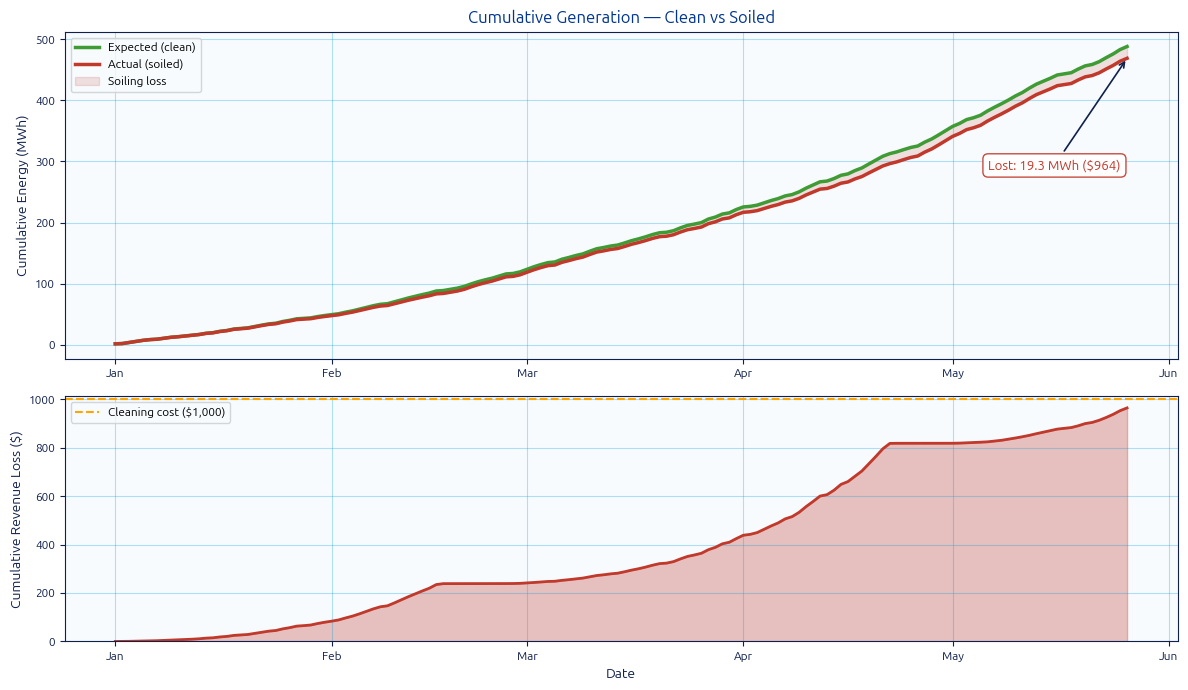

Total soiling loss: 19.3 MWh → $964
Cleaning cost: $1,000 | ROI: 1.0x


In [12]:
# ── Cumulative Revenue Impact & Cleaning ROI ─────────────────────────────────
PPA_RATE = 50.0  # $/MWh

daily_expected = ts_hist['E_Grid'].resample('D').sum() * DT_H / 1e6
daily_actual   = ts_soiled['E_Grid'].resample('D').sum() * DT_H / 1e6
common_days_soiling = daily_expected.index.intersection(daily_actual.index)
daily_expected = daily_expected[common_days_soiling]
daily_actual   = daily_actual[common_days_soiling]

cum_expected = daily_expected.cumsum()
cum_actual   = daily_actual.cumsum()
cum_loss     = cum_expected - cum_actual
cum_revenue_loss = cum_loss * PPA_RATE

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [2, 1.5]})

# Cumulative generation
ax1.plot(common_days_soiling, cum_expected.values, color=DNV['green'], linewidth=2.5,
         label='Expected (clean)')
ax1.plot(common_days_soiling, cum_actual.values, color=DNV['red'], linewidth=2.5,
         label='Actual (soiled)')
ax1.fill_between(common_days_soiling, cum_expected.values, cum_actual.values,
                 alpha=0.15, color=DNV['red'], label='Soiling loss')

final_loss_mwh = float(cum_loss.iloc[-1])
ax1.annotate(
    f'Lost: {final_loss_mwh:.1f} MWh (${final_loss_mwh * PPA_RATE:,.0f})',
    xy=(common_days_soiling[-1], float(cum_actual.iloc[-1])),
    xytext=(-100, -80), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=DNV['navy'], lw=1.2),
    fontsize=9.5, color=DNV['red'],
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=DNV['red'], alpha=0.9),
)
ax1.set_ylabel('Cumulative Energy (MWh)')
ax1.set_title('Cumulative Generation — Clean vs Soiled')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Revenue loss
ax2.fill_between(common_days_soiling, 0, cum_revenue_loss.values, color=DNV['red'], alpha=0.3)
ax2.plot(common_days_soiling, cum_revenue_loss.values, color=DNV['red'], linewidth=2)

CLEANING_COST = 1000
ax2.axhline(CLEANING_COST, color=DNV['warn'], linewidth=1.5, linestyle='--',
            label=f'Cleaning cost (${CLEANING_COST:,})')

breakeven_idx = np.argmax(cum_revenue_loss.values >= CLEANING_COST)
if cum_revenue_loss.values[breakeven_idx] >= CLEANING_COST:
    breakeven_date = common_days_soiling[breakeven_idx]
    ax2.axvline(breakeven_date, color=DNV['warn'], linewidth=1, linestyle=':')
    ax2.annotate(f'Break-even: {breakeven_date.strftime("%d %b")}',
                 xy=(breakeven_date, CLEANING_COST),
                 xytext=(30, 20), textcoords='offset points',
                 fontsize=8.5, color=DNV['warn'],
                 arrowprops=dict(arrowstyle='->', color=DNV['warn']))

ax2.set_ylabel('Cumulative Revenue Loss ($)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"Total soiling loss: {final_loss_mwh:.1f} MWh → ${final_loss_mwh * PPA_RATE:,.0f}")
print(f"Cleaning cost: ${CLEANING_COST:,} | ROI: {final_loss_mwh * PPA_RATE / CLEANING_COST:.1f}x")

### Summary

One 3D model. Three simulations. From bankable P50 to soiling ROI — by swapping only the weather file.

---

<div style="text-align:center; color:#003591; font-size:1.1em;">
<strong>SolarFarmer Python SDK</strong><br>
<a href="https://dnv-opensource.github.io/solarfarmer-python-sdk/">dnv-opensource.github.io/solarfarmer-python-sdk</a>
</div>